In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from autoenkoop import *

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
file = np.load("../../data/T1492_x1151_y1_z127_c2.npz")
data = file['timeseries']

In [3]:
class VelocityDataset(Dataset):
    def __init__(self, data):
        # data: numpy array of shape (t, x, z, v)
        self.X = torch.tensor(data[:-1], dtype=torch.float32).permute(0,3,1,2)
        self.Y = torch.tensor(data[1:], dtype=torch.float32).permute(0,3,1,2)
        # Now shape: (t, v=2, x=1151, z=127)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [4]:
dataset = VelocityDataset(data)
loader = DataLoader(dataset, batch_size=5, shuffle=True)

In [5]:
model = ConvAutoencoder(latent_dim=128).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

n_epochs = 50

loss_reconstruction_history = np.zeros((n_epochs))
loss_prediction_history = np.zeros((n_epochs))
loss_linearity_history = np.zeros((n_epochs))
loss_total_history = np.zeros((n_epochs))
steady_mode_number_history = np.zeros((n_epochs))

steady_tolerance = 0.01

for epoch in range(n_epochs):

    model.train()
    
    reconstruction_loss_epoch = 0.0
    prediction_loss_epoch = 0.0
    linearity_loss_epoch = 0.0
    total_loss_epoch = 0.0
    lingrad_removed_portion_epoch = 0.0

    for x_t, x_t_plus_1 in loader:
        x_t, x_t_plus_1 = x_t.to(DEVICE), x_t_plus_1.to(DEVICE)
        batch_size = x_t.size(0)

        optimizer.zero_grad()
        
        #encoded current state
        z_t = model.encoder(x_t)
        #decoded current state
        reconstructed_x_t = model.decoder(z_t)
        #linear projected encoded next state
        pz_t_plus_1 = model.linear_dynamics(z_t)

        #encoded next state
        z_t_plus_1 = model.encoder(x_t_plus_1)
        reconstructed_x_t_plus_1 = model.decoder(z_t_plus_1)

        ### RECONSTRUCTION LOSS ###
        loss_reconstruction = mse(x_t, reconstructed_x_t) + mse(x_t_plus_1, reconstructed_x_t_plus_1)
        
        #projected decoded next state
        reconstructed_px_t_plus_1 = model.decoder(pz_t_plus_1)

        ### PREDICTION LOSS ###
        #loss_prediction = mse(reconstructed_px_t_plus_1, x_t_plus_1)

        ### LINEARITY LOSS ###
        loss_linearity = mse(pz_t_plus_1,  z_t_plus_1)

        #encoder_params = get_encoder_params(model)

        grads_L_recon = torch.autograd.grad(loss_reconstruction, model.parameters(), retain_graph=True, allow_unused=True)
        grads_L_lin = torch.autograd.grad(loss_linearity, model.parameters(), retain_graph=True, allow_unused=True)
        #grads_L_pred = torch.autograd.grad(loss_prediction, model.parameters(), allow_unused=True)
           
        dot_product = 0
        g_recon_norm = 0
        #g_lin_koop_norm = 0
        #lin_koop_num_param = 0
        g_lin_enc_norm = 0
        #lin_enc_num_param = 0
        #with torch.no_grad():
        for g1, g2 in zip(grads_L_recon, grads_L_lin):
            #print(type(g1), type(g2))
            if g1 is not None and g2 is not None:
                dot_product += torch.dot(g1.view(-1), g2.view(-1))
                g_recon_norm += torch.dot(g1.view(-1), g1.view(-1))
                g_lin_enc_norm += torch.dot(g2.view(-1), g2.view(-1))
                #lin_enc_num_param += g2.view(-1).shape[0]
            #elif g2 is not None:
                #g_lin_koop_norm += torch.dot(g2.view(-1), g2.view(-1))
                #lin_koop_num_param += g2.view(-1).shape[0]
        # flag
        #print("g_lin_koop_norm", g_lin_koop_norm.item())
        #print("lin_koop_num_param", lin_koop_num_param)
        #g_lin_koop_impact = g_lin_koop_norm.item()/lin_koop_num_param
        #print("g_lin_koop_impact", g_lin_koop_impact)
        #print("g_lin_enc_norm", g_lin_enc_norm.item())
        #print("lin_enc_num_param", lin_enc_num_param)
        #g_lin_enc_impact = g_lin_enc_norm.item()/lin_enc_num_param
        #print("g_lin_enc_impact", g_lin_enc_impact)
        #print()
        gradients_conflict = dot_product < 0
        cosine_sim = dot_product / (torch.sqrt(g_recon_norm) * torch.sqrt(g_lin_enc_norm))
        g1_weight = dot_product / g_recon_norm

        g2_weighting = max(0, cosine_sim)
        #print(g2_weight.item())
        for p, g1, g2 in zip(model.parameters(), grads_L_recon, grads_L_lin):#, grads_L_pred):
            #print(p.shape, type(g1), type(g2))
            if g1 is not None and g2 is not None:
                #if gradients_conflict:
                #    final_grad = (1 - g1_weight)*g1 + g2
                #else:
                final_grad = g1 + g2 * g2_weighting
            elif g1 is not None:
                final_grad = g1
            else:
                final_grad = g2 * g2_weighting# min(g_lin_enc_impact/g_lin_koop_impact, 1.0) * g2
            p.grad = final_grad# + g3
        ### TOTAL LOSS ###
        loss_total = loss_reconstruction + loss_linearity# + loss_prediction
        #print(f"Loss(total): {loss_total:.6f}\tLoss(recon): {loss_reconstruction:.6f}\tLoss(lin): {loss_linearity:.6f}\tCossim(recon,lin): {cosine_sim:.6f}") #\tLoss(pred): {loss_prediction:.4f}
        #loss_total.backward()
        optimizer.step()
        
        #if gradients_conflict:
        #    lingrad_removed_portion_epoch += g_recon_norm * batch_size
        reconstruction_loss_epoch += loss_reconstruction.item() * batch_size
        #prediction_loss_epoch += loss_prediction.item() * batch_size
        linearity_loss_epoch += loss_linearity.item() * batch_size
        total_loss_epoch += loss_total.item() * batch_size

    # calculate epoch loss mean
    num_examples = len(loader.dataset)

    reconstruction_loss_mean = reconstruction_loss_epoch / num_examples
    prediction_loss_mean = prediction_loss_epoch / num_examples
    linearity_loss_mean = linearity_loss_epoch / num_examples
    total_loss_mean = total_loss_epoch / num_examples
    lingrad_removed_portion_mean = lingrad_removed_portion_epoch / num_examples
    
    loss_reconstruction_history[epoch] = reconstruction_loss_mean
    loss_prediction_history[epoch] = prediction_loss_mean
    loss_linearity_history[epoch] = linearity_loss_mean
    loss_total_history[epoch] = total_loss_mean

    with torch.no_grad():
        K = model.linear_dynamics.weight.detach().cpu().numpy()
    eigvals, eigvecs = np.linalg.eig(K)
    
    max_abs_eigenvalue = np.max(np.abs(eigvals))

    mask = np.abs((np.abs(eigvals) - 1.0)) < steady_tolerance
    steady_mode_number_history[epoch] = sum(mask)
        #break
    print(f"Epoch {epoch+1}/{n_epochs}\tLoss(total): {total_loss_mean:.4f}\tLoss(recon): {reconstruction_loss_mean:.4f}\tLoss(pred): {prediction_loss_mean:.4f}\tLoss(lin): {linearity_loss_mean:.6f}\tMaxAbsEigenV: {max_abs_eigenvalue:.4f}\tSteadyModes: {sum(mask)}\tLinGradRemovedPortion: {lingrad_removed_portion_mean:.4f}")

Epoch 1/50	Loss(total): 27.9212	Loss(recon): 0.7091	Loss(pred): 0.0000	Loss(lin): 27.212049	MaxAbsEigenV: 0.6603	SteadyModes: 0	LinGradRemovedPortion: 0.0000
Epoch 2/50	Loss(total): 0.4989	Loss(recon): 0.2201	Loss(pred): 0.0000	Loss(lin): 0.278757	MaxAbsEigenV: 0.6750	SteadyModes: 0	LinGradRemovedPortion: 0.0000
Epoch 3/50	Loss(total): 0.3170	Loss(recon): 0.1877	Loss(pred): 0.0000	Loss(lin): 0.129306	MaxAbsEigenV: 0.7383	SteadyModes: 0	LinGradRemovedPortion: 0.0000
Epoch 4/50	Loss(total): 0.2820	Loss(recon): 0.1662	Loss(pred): 0.0000	Loss(lin): 0.115831	MaxAbsEigenV: 0.7947	SteadyModes: 0	LinGradRemovedPortion: 0.0000
Epoch 5/50	Loss(total): 0.2528	Loss(recon): 0.1470	Loss(pred): 0.0000	Loss(lin): 0.105737	MaxAbsEigenV: 0.8946	SteadyModes: 0	LinGradRemovedPortion: 0.0000
Epoch 6/50	Loss(total): 0.2486	Loss(recon): 0.1355	Loss(pred): 0.0000	Loss(lin): 0.113115	MaxAbsEigenV: 0.9559	SteadyModes: 0	LinGradRemovedPortion: 0.0000
Epoch 7/50	Loss(total): 0.2336	Loss(recon): 0.1239	Loss(pred):

In [6]:
torch.save(model.state_dict(), "model_gp_20260216_1400.pt")

In [7]:
with torch.no_grad():
    K = model.linear_dynamics.weight.detach().cpu().numpy()
eigvals, eigvecs = np.linalg.eig(K)

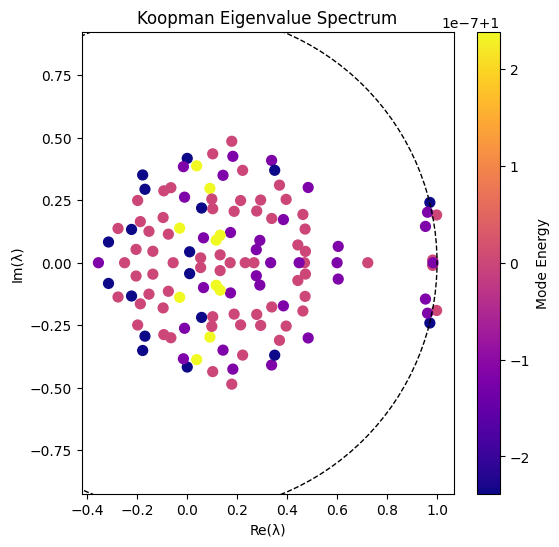

In [8]:
energies = np.linalg.norm(eigvecs, axis=0)**2

plt.figure(figsize=(6,6))
sc = plt.scatter(np.real(eigvals), np.imag(eigvals),
                 c=energies, cmap='plasma', s=50)
plt.colorbar(sc, label="Mode Energy")
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.title("Koopman Eigenvalue Spectrum")
circle = plt.Circle((0,0), 1.0, color='k', fill=False, linestyle='--')
plt.gca().add_artist(circle)
plt.axis('equal')
plt.show()

In [10]:
steady_tolerance = 0.02
mask = np.abs((np.abs(eigvals) - 1.0)) < steady_tolerance
print(sum(mask))
eigvals_nondecay = eigvals[mask]
modes_nondecay = eigvecs[:, mask]
# to torch cuda
E_nondecay = torch.tensor(eigvals_nondecay, dtype=torch.complex64,device=DEVICE)
V_nondecay = torch.tensor(modes_nondecay, dtype=torch.complex64, device=DEVICE)

9


In [12]:
x0, _ = dataset[0]
x0 = x0.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    z0 = model.encoder(x0)

z0 = z0.squeeze(0).to(torch.complex64)
# Compute coefficients in modal basis
c0 = torch.linalg.pinv(V_nondecay) @ z0

def koopman_evolve(t):
    Lambda_t_diag = torch.diag(torch.exp(torch.log(E_nondecay) * t))
    z_t_complex = V_nondecay @ Lambda_t_diag @ c0
    return z_t_complex.real.unsqueeze(0)

def reconstruct_state(t):
    z_t_predicted = koopman_evolve(t)
    x_t_reconstructed = model.decoder(z_t_predicted)
    return x_t_reconstructed.squeeze(0)

In [17]:
steady_state_prediction = []
with torch.no_grad():
    for t in range(1000):
        reconstructed_x_t = reconstruct_state(t).cpu().numpy()
        steady_state_prediction.append(reconstructed_x_t)

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

vx_all = data[..., 0]
vz_all = data[..., 1]

vx_min, vx_max = np.min(vx_all), np.max(vx_all)
vz_min, vz_max = np.min(vz_all), np.max(vz_all)

norm_x = Normalize(vmin=vx_min, vmax=vx_max)
norm_z = Normalize(vmin=vz_min, vmax=vz_max)

def plot_vx_vz(vx, vz):

    plt.figure(figsize=(10,8))

    # --- vx ---
    plt.subplot(2,1,1)
    plt.imshow(vx.T, origin='lower', aspect='auto', cmap='viridis', norm=norm_x)
    plt.colorbar(label='vx')
    plt.title(f"vx")
    plt.xlabel("x-coordinate")
    plt.ylabel("z-coordinate")

    # --- vz ---
    plt.subplot(2,1,2)
    plt.imshow(vz.T, origin='lower', aspect='auto', cmap='plasma', norm=norm_z)
    plt.colorbar(label='vz')
    plt.title(f"vz")
    plt.xlabel("x-coordinate")
    plt.ylabel("z-coordinate")

    plt.tight_layout()
    plt.show()


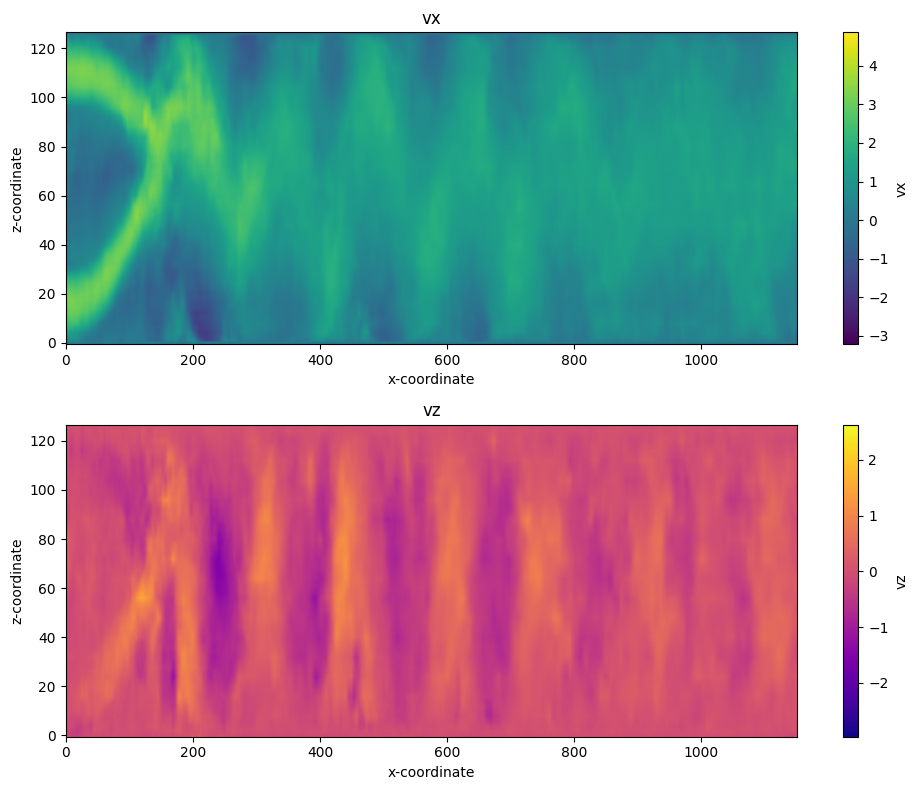

In [21]:
x_t_stable = steady_state_prediction[999]
vx = x_t_stable[0,:]
vz = x_t_stable[1,:]

plot_vx_vz(vx, vz)

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199


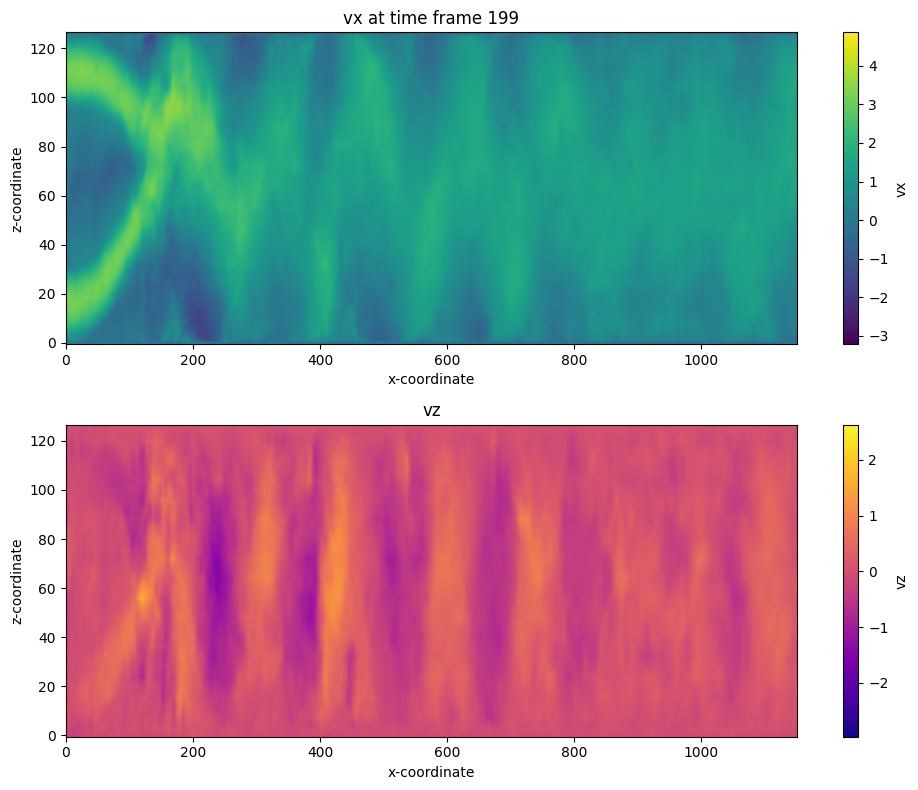

In [22]:
from matplotlib.animation import FuncAnimation, PillowWriter

n_timesteps = len(steady_state_prediction)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Initialize first frame
vx = steady_state_prediction[0][0,:]
vz = steady_state_prediction[0][1,:]

im_vx = axes[0].imshow(vx.T, origin='lower', aspect='auto', cmap='viridis', norm=norm_x)
axes[0].set_title("vx at time frame 0")
axes[0].set_xlabel("x-coordinate")
axes[0].set_ylabel("z-coordinate")
fig.colorbar(im_vx, ax=axes[0], label="vx")

im_vz = axes[1].imshow(vz.T, origin='lower', aspect='auto', cmap='plasma', norm=norm_z)
axes[1].set_title("vz")
axes[1].set_xlabel("x-coordinate")
axes[1].set_ylabel("z-coordinate")
fig.colorbar(im_vz, ax=axes[1], label="vz")

plt.tight_layout()

def update(frame):
    print(frame)
    vx = steady_state_prediction[frame][0,:]
    vz = steady_state_prediction[frame][1,:]
    
    im_vx.set_data(vx.T)
    im_vz.set_data(vz.T)
    
    axes[0].set_title(f"vx at time frame {frame}")
    #axes[1].set_title(f"vz")
    
    return [im_vx, im_vz]

ani = FuncAnimation(fig, update,
                    frames=range(200),
                    interval=30,
                    blit=False)

# Save as GIF (requires Pillow)
writer = PillowWriter(fps=20)
ani.save("velocity_field_steadyG_9_200.gif", writer=writer)

plt.show()

In [ ]:
model.eval()
mse_list = []

with torch.no_grad():
    for x_t_true, x_t_plus_1_true in dataset:
        #vx_true = x_true[0]
        #vz_true = x_true[1]
        #plot_vx_vz(vx_true, vz_true)
        x_true = x_t_true.unsqueeze(0).to('cuda')
        x_pred = model(x_true).squeeze(0).cpu()
        #vx_pred = x_pred[0]
        #vz_pred = x_pred[1]
        #plot_vx_vz(vx_pred, vz_pred)
        #vx_diff = (vx_true - vx_pred)**2
        #vz_diff = (vz_true - vz_pred)**2
        mse_list.append(np.mean((x_true.to('cpu').numpy() - x_pred.numpy())**2))
        #plot_vx_vz(vx_diff, vz_diff)
        #print(np.sum(vz_diff.numpy()))
        #print(np.sum(vz_diff.numpy()))
        #print()
        ##

In [ ]:
mse_list = np.array(mse_list)

In [ ]:
np.mean(mse_list)

In [ ]:
mse_list